# **Clean Dataset**

## **Import Data**

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import os
import re
import json
import string
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
%pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.0 MB/s eta 0:00:00


In [ ]:
# Load file CSV
url = 'https://drive.google.com/uc?id=1AquDcY68zFoltVYPjd6p2CLeVOYZRB6U'
tka = pd.read_csv(url)
tka.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1.940000e+18,2025-05-29 09:06:06+00:00,0,YA ALLAH CAPEKBGTT BELAJAR TKA,1.940000e+18,NaN,NaN,in,NaN,0,0,0,https://x.com/heeseungunair/status/19393460528...,1.650000e+18,heeseungunair
1,1.960000e+18,2025-05-29 14:24:07+00:00,2,hiii tmntmn ada yang punya server discord buat...,1.960000e+18,NaN,NaN,in,NaN,0,0,2,https://x.com/parfaither/status/19560070653837...,1.830000e+18,parfaither
2,1.930000e+18,2025-05-29 18:02:02+00:00,0,"pusing bgt, kalian bljr TKA nya langsung latso...",1.930000e+18,NaN,NaN,in,NaN,0,1,0,https://x.com/hachiphuw/status/192884612576462...,1.360000e+18,hachiphuw
3,1.940000e+18,2025-05-30 03:15:56+00:00,0,Sekolah macam apa yg sampe hari ini belum shar...,1.940000e+18,NaN,NaN,in,NaN,0,3,0,https://x.com/yunjinrawr/status/19396679593683...,1.510000e+18,yunjinrawr
4,1.940000e+18,2025-05-30 04:02:58+00:00,0,"bentar ya cowo kpopku, tungguin aku kelar tka ...",1.940000e+18,NaN,NaN,in,NaN,0,2,0,https://x.com/ambisiuss01/status/1939665333503...,1.680000e+18,ambisiuss01


In [ ]:
tka.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4439 entries, 0 to 4438
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      4439 non-null   float64
 1   created_at               4439 non-null   object 
 2   favorite_count           4439 non-null   int64  
 3   full_text                4439 non-null   object 
 4   id_str                   4439 non-null   float64
 5   image_url                0 non-null      float64
 6   in_reply_to_screen_name  162 non-null    object 
 7   lang                     4439 non-null   object 
 8   location                 0 non-null      float64
 9   quote_count              4439 non-null   int64  
 10  reply_count              4439 non-null   int64  
 11  retweet_count            4439 non-null   int64  
 12  tweet_url                4439 non-null   object 
 13  user_id_str              4439 non-null   float64
 14  username                

In [ ]:
# Kolom 'full_text'
df = tka[['full_text']]
df.head()

,full_text
0,YA ALLAH CAPEKBGTT BELAJAR TKA
1,hiii tmntmn ada yang punya server discord buat...
2,"pusing bgt, kalian bljr TKA nya langsung latso..."
3,Sekolah macam apa yg sampe hari ini belum shar...
4,"bentar ya cowo kpopku, tungguin aku kelar tka ..."


In [ ]:
# Menghapus duplikasi data
df.drop_duplicates(subset='full_text', keep = 'first', inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4439 entries, 0 to 4438
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  4439 non-null   object
dtypes: object(1)
memory usage: 34.8+ KB


/tmp/ipykernel_633/1509910024.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(subset='full_text', keep = 'first', inplace=True)


# **Preprocessing Data**

## _**Casefolding**_

In [ ]:
def case_folding(text):
    if isinstance(text, str):
      lowercased_text = text.lower()
      return lowercased_text
    else:
      return text

df['casefolding'] = df['full_text'].apply(case_folding)
df.head(5)

/tmp/ipykernel_633/2510011189.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['casefolding'] = df['full_text'].apply(case_folding)


,full_text,casefolding
0,YA ALLAH CAPEKBGTT BELAJAR TKA,ya allah capekbgtt belajar tka
1,hiii tmntmn ada yang punya server discord buat...,hiii tmntmn ada yang punya server discord buat...
2,"pusing bgt, kalian bljr TKA nya langsung latso...","pusing bgt, kalian bljr tka nya langsung latso..."
3,Sekolah macam apa yg sampe hari ini belum shar...,sekolah macam apa yg sampe hari ini belum shar...
4,"bentar ya cowo kpopku, tungguin aku kelar tka ...","bentar ya cowo kpopku, tungguin aku kelar tka ..."


## _**Cleaning data**_

In [ ]:
# Menghapus Emoji dan Bendera
def remove_emoji(text):
    if text is not None and isinstance(text, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F700-\U0001F77F"  # alchemical symbols
            u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
            u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
            u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
            u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
            u"\U00002702-\U000027B0"  # Dingbats
            u"\U000024C2-\U0001F251"  # Enclosed characters
            u"\U0001F1E0-\U0001F1FF"  # Regional indicator symbol (bendera)
            "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', text)
    return text
# Menghapus Emotikon berbasis karakter seperti :) :( :v
def remove_emoticon(text):
    if text is not None and isinstance(text, str):
        emoticon_pattern = r'[:;=8xX][-^o*]?[)(DPpOo3|/\\]'
        return re.sub(emoticon_pattern, '', text)
    return text
# Menghapus Username (mention)
def remove_username(text):
    return re.sub(r'@\w+', '', text)
# Menghapus URL atau Link
def remove_links(text):
    return re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
# Menghapus Simbol selain huruf dan angka
def remove_symbols(text):
    if text is not None and isinstance(text, str):
        return re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text
# Menghapus Angka
def remove_numbers(text):
    return re.sub(r'\d+', '', text)
# Menghapus kata berulang (misal: "aaaaaa" jadi "a", "haaaallo" jadi "halo")
def remove_repeated_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1', text)
# Mengubah newline atau enter (\n) menjadi spasi
def remove_newline(text):
    return text.replace('\n', ' ').replace('\r', ' ')
# Menghapus spasi berlebihan
def remove_extra_whitespace(text):
    return re.sub(r'\s+', ' ', text).strip()
# Menghapus trigger word menfess seperti sch!, ptn!, stud!, dll.
def remove_menfess(text):
    if text is not None and isinstance(text, str):
        trigger_words = ["sch", "ptn", "stud", "colle","buten"]
        pattern = r'\b(' + '|'.join(trigger_words) + r')\s*!+'
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)
        return text
    return text
# Gabungkan semua fungsi jadi satu pipeline
def clean_text(text):
    text = remove_username(text)
    text = remove_links(text)
    text = remove_emoji(text)
    text = remove_emoticon(text)
    text = remove_menfess(text)
    text = remove_symbols(text)
    text = remove_numbers(text)
    text = remove_repeated_chars(text)
    text = remove_newline(text)
    text = remove_extra_whitespace(text)
    return text
df['cleaning'] = df['casefolding'].apply(clean_text)
# Hapus baris yang kosong setelah dibersihkan
df = df[df['cleaning'].str.strip() != '']
df.head()

/tmp/ipykernel_633/779245365.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cleaning'] = df['casefolding'].apply(clean_text)


,full_text,casefolding,cleaning
0,YA ALLAH CAPEKBGTT BELAJAR TKA,ya allah capekbgtt belajar tka,ya allah capekbgtt belajar tka
1,hiii tmntmn ada yang punya server discord buat...,hiii tmntmn ada yang punya server discord buat...,hi tmntmn ada yang punya server discord buat d...
2,"pusing bgt, kalian bljr TKA nya langsung latso...","pusing bgt, kalian bljr tka nya langsung latso...",pusing bgt kalian bljr tka nya langsung latsol...
3,Sekolah macam apa yg sampe hari ini belum shar...,sekolah macam apa yg sampe hari ini belum shar...,sekolah macam apa yg sampe hari ini belum shar...
4,"bentar ya cowo kpopku, tungguin aku kelar tka ...","bentar ya cowo kpopku, tungguin aku kelar tka ...",bentar ya cowo kpopku tungguin aku kelar tka a...


## _**Normalization**_ **(Mengubah kata tidak baku menjadi baku)**

In [ ]:
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kata_diganti = []
        kata_baku = []

        for word in words:
            word_clean = word.lower().strip()

            if word_clean in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word_clean]
                replaced_words.append(baku_word)
                kata_diganti.append(word_clean)
                kata_baku.append(baku_word)
            else:
                replaced_words.append(word)

        replaced_text = ' '.join(replaced_words)
        return replaced_text, kata_baku, kata_diganti

    return '', [], []

In [ ]:
# Menggunakan kamuskatabaku dari www.kaggle.com/datasets/fornigulo/kamuskatabaku
sheet_id = "1z68haLNKapFm18s0o_76XKdJs-ykd3gO"
kamuskatabaku = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=xlsx"
kamus_data = pd.read_excel(kamuskatabaku)
kamus_tidak_baku = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))

In [ ]:
df['normalized'], df['kata_baku'], df['kata_tidak_baku'] = zip(
    *df['cleaning'].apply(lambda x: replace_taboo_words(x, kamus_tidak_baku))
)

df = df[['full_text', 'casefolding', 'cleaning', 'normalized']]
df.head(5)

,full_text,casefolding,cleaning,normalized
0,YA ALLAH CAPEKBGTT BELAJAR TKA,ya allah capekbgtt belajar tka,ya allah capekbgtt belajar tka,ya allah capek banget belajar tka
1,hiii tmntmn ada yang punya server discord buat...,hiii tmntmn ada yang punya server discord buat...,hi tmntmn ada yang punya server discord buat d...,hi teman teman ada yang punya server discord b...
2,"pusing bgt, kalian bljr TKA nya langsung latso...","pusing bgt, kalian bljr tka nya langsung latso...",pusing bgt kalian bljr tka nya langsung latsol...,pusing banget kalian belajar tka nya langsung ...
3,Sekolah macam apa yg sampe hari ini belum shar...,sekolah macam apa yg sampe hari ini belum shar...,sekolah macam apa yg sampe hari ini belum shar...,sekolah macam apa yang sampai hari ini belum s...
4,"bentar ya cowo kpopku, tungguin aku kelar tka ...","bentar ya cowo kpopku, tungguin aku kelar tka ...",bentar ya cowo kpopku tungguin aku kelar tka a...,bentar ya cowok kpopku tungguin aku kelar tka ...


In [ ]:
# Menampilkan baris indeks 0, 3, dan 4
df.iloc[[0, 3, 4]]

,full_text,casefolding,cleaning,normalized
0,YA ALLAH CAPEKBGTT BELAJAR TKA,ya allah capekbgtt belajar tka,ya allah capekbgtt belajar tka,ya allah capek banget belajar tka
3,Sekolah macam apa yg sampe hari ini belum shar...,sekolah macam apa yg sampe hari ini belum shar...,sekolah macam apa yg sampe hari ini belum shar...,sekolah macam apa yang sampai hari ini belum s...
4,"bentar ya cowo kpopku, tungguin aku kelar tka ...","bentar ya cowo kpopku, tungguin aku kelar tka ...",bentar ya cowo kpopku tungguin aku kelar tka a...,bentar ya cowok kpopku tungguin aku kelar tka ...


## **Drop data kosong dan duplikasi**

In [ ]:
data = df.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4439 entries, 0 to 4438
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   full_text    4439 non-null   object
 1   casefolding  4439 non-null   object
 2   cleaning     4439 non-null   object
 3   normalized   4439 non-null   object
dtypes: object(4)
memory usage: 138.8+ KB


In [ ]:
# Hitung jumlah baris sebelum menghapus duplikasi
before_drop = len(df)
# Hapus duplikasi berdasarkan kolom 'normalized'
df.drop_duplicates(subset='normalized', keep='first', inplace=True)
# Hitung jumlah baris setelah menghapus duplikasi
after_drop = len(df)
# Hitung jumlah baris yang dihapus
dropped = before_drop - after_drop
print(f"Jumlah baris yang dihapus: {dropped}")

Jumlah baris yang dihapus: 19


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4420 entries, 0 to 4438
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   full_text    4420 non-null   object
 1   casefolding  4420 non-null   object
 2   cleaning     4420 non-null   object
 3   normalized   4420 non-null   object
dtypes: object(4)
memory usage: 172.7+ KB


In [ ]:
# Ambil kolom yang dibutuhkan
df_ready = df[['full_text', 'normalized']]
df_ready.head()

,full_text,normalized
0,YA ALLAH CAPEKBGTT BELAJAR TKA,ya allah capek banget belajar tka
1,hiii tmntmn ada yang punya server discord buat...,hi teman teman ada yang punya server discord b...
2,"pusing bgt, kalian bljr TKA nya langsung latso...",pusing banget kalian belajar tka nya langsung ...
3,Sekolah macam apa yg sampe hari ini belum shar...,sekolah macam apa yang sampai hari ini belum s...
4,"bentar ya cowo kpopku, tungguin aku kelar tka ...",bentar ya cowok kpopku tungguin aku kelar tka ...


In [ ]:
# Simpan ke file CSV
df_ready.to_csv("tka_cleaned.csv", index=False)

# **Labeling**

In [ ]:
# Library umum
import pandas as pd
import torch
from tqdm import tqdm

# Transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax

In [ ]:
# Load data hasil preprocessing
df = pd.read_csv("tka_cleaned.csv")
df.head()

,full_text,normalized
0,YA ALLAH CAPEKBGTT BELAJAR TKA,ya allah capek banget belajar tka
1,hiii tmntmn ada yang punya server discord buat...,hi teman teman ada yang punya server discord b...
2,"pusing bgt, kalian bljr TKA nya langsung latso...",pusing banget kalian belajar tka nya langsung ...
3,Sekolah macam apa yg sampe hari ini belum shar...,sekolah macam apa yang sampai hari ini belum s...
4,"bentar ya cowo kpopku, tungguin aku kelar tka ...",bentar ya cowok kpopku tungguin aku kelar tka ...


In [ ]:
# Gunakan model BERT pretrained
model_name = "mdhugol/indonesia-bert-sentiment-classification"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval();  # masuk ke mode evaluasi

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: mdhugol/indonesia-bert-sentiment-classification
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Lihat mapping label
print(model.config.id2label)

# Mapping label
label_map = {
    0: 'positive',
    1: 'neutral',
    2: 'negative'
}

{0: 'LABEL_0', 1: 'LABEL_1', 2: 'LABEL_2'}


In [ ]:
# Confidence threshold
THRESHOLD = 0.7

def predict_sentiment(text):
    clean_text = str(text).lower().strip()

    # Jika hanya "tka" atau "tes kompetensi akademik", auto netral
    if clean_text in ["tka", "tes kompetensi akademik", "tes kemampuan akademik"]:
        return 1, 1.0

    # Prediksi dengan model
    inputs = tokenizer(
        clean_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    )

    with torch.no_grad():
        outputs = model(**inputs)
        probs = softmax(outputs.logits, dim=1)
        max_prob, predicted = torch.max(probs, dim=1)

        predicted = predicted.item()
        max_prob = max_prob.item()
        return predicted, label_map[predicted], max_prob

In [ ]:
# Simpan jumlah data awal sebelum filtering
jumlah_awal = len(df)

# Tampilkan progress bar
tqdm.pandas()

# Prediksi sentimen
results = df['normalized'].progress_apply(predict_sentiment)

# Pisahkan hasil prediksi
df['label_num_all'] = results.apply(lambda x: x[0])
df['pseudo_label_all'] = results.apply(lambda x: x[1])
df['confidence_score'] = results.apply(lambda x: x[2])

# Distribusi sebelum threshold
print("Jumlah data sebelum threshold:", len(df))
print("\nDistribusi label sebelum threshold:")
print(df['pseudo_label_all'].value_counts())

print("\nDistribusi label sebelum threshold (%):")
print((df['pseudo_label_all'].value_counts(normalize=True) * 100).round(2))

100%|██████████| 4420/4420 [09:39<00:00,  7.63it/s]

Jumlah data sebelum threshold: 4420

Distribusi label sebelum threshold:
pseudo_label_all
negative    2283
neutral     1463
positive     674
Name: count, dtype: int64

Distribusi label sebelum threshold (%):
pseudo_label_all
negative    51.65
neutral     33.10
positive    15.25
Name: proportion, dtype: float64


In [ ]:
# Seleksi berdasarkan threshold
labeled_df = df[df['confidence_score'] >= THRESHOLD].copy()
low_confidence_df = df[df['confidence_score'] < THRESHOLD].copy()

# Setelah threshold, gunakan nama kolom final
labeled_df['label_num'] = labeled_df['label_num_all'].astype(int)
labeled_df['pseudo_label'] = labeled_df['pseudo_label_all']

# Reset index
labeled_df.reset_index(drop=True, inplace=True)
low_confidence_df.reset_index(drop=True, inplace=True)

In [ ]:
# Statistik filtering
print("\nJumlah data awal:", jumlah_awal)
print("Jumlah data lolos threshold:", len(labeled_df))
print("Jumlah data dibuang:", len(low_confidence_df))
print("Persentase data dibuang:", round(len(low_confidence_df) / jumlah_awal * 100, 2), "%")



Jumlah data awal: 4420
Jumlah data lolos threshold: 3769
Jumlah data dibuang: 651
Persentase data dibuang: 14.73 %


In [ ]:
# Distribusi setelah threshold
print("\nDistribusi label setelah threshold:")
print(labeled_df['pseudo_label'].value_counts())

print("\nDistribusi label setelah threshold (%):")
print((labeled_df['pseudo_label'].value_counts(normalize=True) * 100).round(2))



Distribusi label setelah threshold:
pseudo_label
negative    2041
neutral     1211
positive     517
Name: count, dtype: int64

Distribusi label setelah threshold (%):
pseudo_label
negative    54.15
neutral     32.13
positive    13.72
Name: proportion, dtype: float64


In [ ]:
# Distribusi data yang dibuang berdasarkan prediksi awal
print("\nDistribusi data confidence rendah berdasarkan prediksi awal:")
print(low_confidence_df['pseudo_label_all'].value_counts())

print("\nDistribusi data confidence rendah berdasarkan prediksi awal (%):")
print((low_confidence_df['pseudo_label_all'].value_counts(normalize=True) * 100).round(2))



Distribusi data confidence rendah berdasarkan prediksi awal:
pseudo_label_all
neutral     252
negative    242
positive    157
Name: count, dtype: int64

Distribusi data confidence rendah berdasarkan prediksi awal (%):
pseudo_label_all
neutral     38.71
negative    37.17
positive    24.12
Name: proportion, dtype: float64


In [ ]:
# Simpan hasil
df.to_csv("label_utuh.csv", index=False)
labeled_df.to_csv("tka_labeled.csv", index=False)
low_confidence_df.to_csv("low_conf.csv", index=False)


In [ ]:
# Tampilkan beberapa data confidence rendah
display(low_confidence_df[['normalized', 'pseudo_label_all', 'confidence_score']].head(20))

,normalized,pseudo_label_all,confidence_score
0,ya allah h tka malah flu gegara seminggu kemar...,negative,0.560773
1,kegiatan yang pengin dilakuin habis tka main r...,positive,0.552641
2,tka nih konsepnya bagaimana sih guys yang angk...,neutral,0.542291
3,hm masih mempertimbangkan beli buku tka apa ti...,negative,0.487841
4,hi izin qrt ya coba pakai rg yang rubelnya saj...,positive,0.690706
5,planning libur smt sudah numpuk ya belajar tka...,neutral,0.449762
6,mau nanyaa dong tka tuh mata pelajaran pilihan...,neutral,0.461821
7,reminder saja h tka,negative,0.684354
8,karena sudah lama tidak nyentuh fisika nih ide...,positive,0.535060
9,kalau tkakan masuk nanti eligible ya berarti a...,positive,0.477336


In [ ]:
# Hasil label
labeled_df[['normalized', 'label_num', 'pseudo_label','confidence_score']].head()

,normalized,label_num,pseudo_label,confidence_score
0,ya allah capek banget belajar tka,2,negative,0.997997
1,hi teman teman ada yang punya server discord b...,1,neutral,0.984676
2,pusing banget kalian belajar tka nya langsung ...,2,negative,0.997614
3,sekolah macam apa yang sampai hari ini belum s...,2,negative,0.995759
4,bentar ya cowok kpopku tungguin aku kelar tka ...,1,neutral,0.740237


# Label final

Data yang tidak lolos treshold dilabeli secara manual dan digabungkan kembali ke data awal


In [ ]:
import pandas as pd
label_final = pd.read_csv('final_labeled.csv')

In [ ]:
# Distribusi data yang dibuang berdasarkan prediksi awal
print("\nDistribusi data confidence rendah berdasarkan prediksi awal:")
print(label_final['pseudo_label'].value_counts())

print("\nDistribusi data confidence rendah berdasarkan prediksi awal (%):")
print((label_final['pseudo_label'].value_counts(normalize=True) * 100).round(2))



Distribusi data confidence rendah berdasarkan prediksi awal:
pseudo_label
negative    2229
neutral     1528
positive     663
Name: count, dtype: int64

Distribusi data confidence rendah berdasarkan prediksi awal (%):
pseudo_label
negative    50.43
neutral     34.57
positive    15.00
Name: proportion, dtype: float64


# Pembagian data

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Memuat dataset
tweet_labeled = pd.read_csv('final_labeled.csv')
# Memisahkan data latih (70%) dan sisanya (30%)
train_data, temp_data = train_test_split(tweet_labeled, test_size=0.3, random_state=42,
                                         stratify=tweet_labeled['label_num'])

# Memisahkan data validasi (10%) dan data uji (20%) dari sisa data
val_data, test_data = train_test_split(temp_data, test_size=2/3, random_state=42,
                                       stratify=temp_data['label_num'])

# Menyimpan masing-masing dataset ke file CSV
train_data.to_csv('train_dataset.csv', index=False)
val_data.to_csv('val_dataset.csv', index=False)
test_data.to_csv('test_dataset.csv', index=False)

# Menampilkan jumlah data masing-masing
print(f"Jumlah data latih: {len(train_data)}")
print(f"Jumlah data validasi: {len(val_data)}")
print(f"Jumlah data uji: {len(test_data)}")

Jumlah data latih: 3094
Jumlah data validasi: 442
Jumlah data uji: 884


## Wordcloud

In [ ]:
!pip install wordcloud

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from collections import Counter

In [ ]:
label_map = {
    "positive": "positif",
    "neutral": "netral",
    "negative": "negatif",
    "positif": "positif",
    "netral": "netral",
    "negatif": "negatif"
}
df["sentimen"] = df["pseudo_label"].map(label_map)
print(df["sentimen"].value_counts())


sentimen
negatif    2041
netral     1211
positif     517
Name: count, dtype: int64


In [ ]:
stopwords_id = set([
    "yang", "dan", "di", "ke", "dari", "ini", "itu", "untuk", "dengan",
    "karena", "pada", "ada", "jadi", "atau", "dalam", "akan", "bisa",
    "sudah", "belum", "saja", "aja", "aku", "saya", "gue", "gua", "gw",
    "kamu", "dia", "mereka", "kita", "kami", "nya", "nih", "dong",
    "sih", "deh", "lah", "pun", "ya", "yaitu", "adalah", "sebagai",
    "juga", "lebih", "kurang", "sangat", "banget", "bgt", "gak", "ga",
    "nggak", "tidak", "tak", "kalau", "kalo", "kan", "kok", "mah",
    "rt", "amp", "guys","sama", "mau", "buat", "apa", "semua", "orang",
    "banget", "lagi", "udah", "udahh", "aja", "cuma", "kayak","tapi",
    "kaya", "gitu", "gini", "dong", "nih","apa","bagaimana","kenapa",
    "kalian","masih","punya","harus","snbt","mata","kah","kan","kak",
    "tuh","banyak","tau","sampai","soalnya","habis","hari","benar"
])

# Kata khusus topik yang boleh dihapus jika terlalu dominan
stopwords_topik = set([
    "tka", "tes", "kemampuan", "akademik", "soal", "sekolah", "siswa",
    "ujian", "belajar","nilai","utbk","kelas","tiga","try","out"
])
stopwords_final = stopwords_id.union(stopwords_topik)

In [ ]:
def get_words(text_series, stopwords):
    all_text = " ".join(text_series.dropna().astype(str))
    words = all_text.split()

    cleaned_words = []
    for word in words:
        word = word.strip().lower()
        if len(word) > 2 and word not in stopwords:
            cleaned_words.append(word)

    return cleaned_words


def get_top_words(text_series, stopwords, top_n=20):
    words = get_words(text_series, stopwords)
    counter = Counter(words)
    return counter.most_common(top_n)

In [ ]:
from collections import Counter
import pandas as pd

def get_words(text_series, stopwords):
    all_text = " ".join(text_series.dropna().astype(str))
    words = all_text.split()

    cleaned_words = []
    for word in words:
        word = word.strip().lower()
        if len(word) > 2 and word not in stopwords:
            cleaned_words.append(word)

    return cleaned_words


def get_top_words(text_series, stopwords, top_n=20):
    words = get_words(text_series, stopwords)
    counter = Counter(words)
    return counter.most_common(top_n)


sentimen_order = ["negatif", "netral", "positif"]

top_words_all = []

for sentimen in sentimen_order:
    data_sentimen = df[df["sentimen"] == sentimen]
    top_words = get_top_words(data_sentimen["normalized"], stopwords_final, top_n=20)

    for rank, (word, freq) in enumerate(top_words, start=1):
        top_words_all.append({
            "sentimen": sentimen,
            "peringkat": rank,
            "kata": word,
            "frekuensi": freq
        })

top_words_df = pd.DataFrame(top_words_all)

top_10_words = []

for sentimen in sentimen_order:
    subset = top_words_df[top_words_df["sentimen"] == sentimen].head(30)
    kata_dominan = ", ".join(subset["kata"].tolist())

    top_10_words.append({
        "Sentimen": sentimen.capitalize(),
        "Kata Dominan": kata_dominan
    })

top_10_words_df = pd.DataFrame(top_10_words)
top_10_words_df

,Sentimen,Kata Dominan
0,Negatif,"susah, matematika, tolong, bingung, pelajaran,..."
1,Netral,"pelajaran, materi, matematika, buku, ambil, la..."
2,Positif,"semoga, bagus, semangat, allah, alhamdulillah,..."


In [ ]:
def create_wordcloud(text_series, stopwords, title, filename):
    words = get_words(text_series, stopwords)
    text = " ".join(words)

    wordcloud = WordCloud(
        width=1200,
        height=800,
        background_color="white",
        stopwords=stopwords,
        collocations=False,
        max_words=100
    ).generate(text)

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

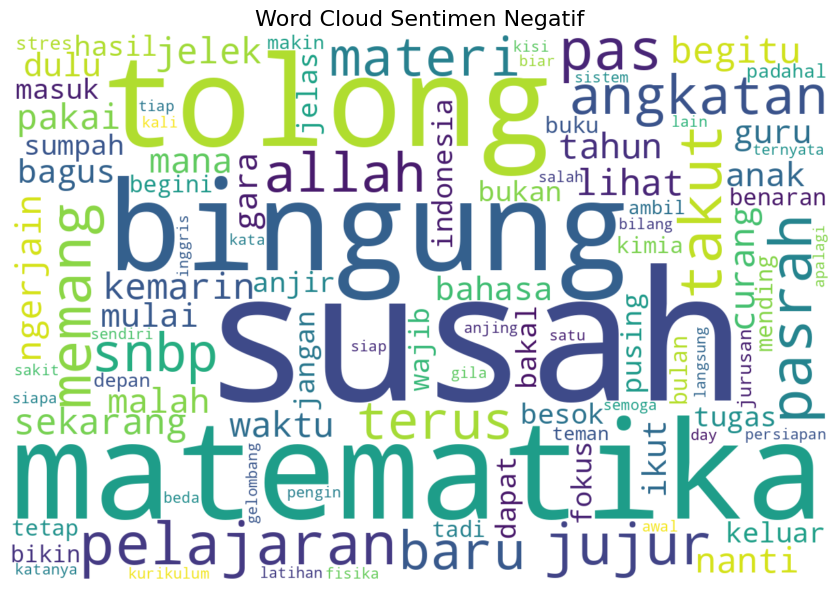

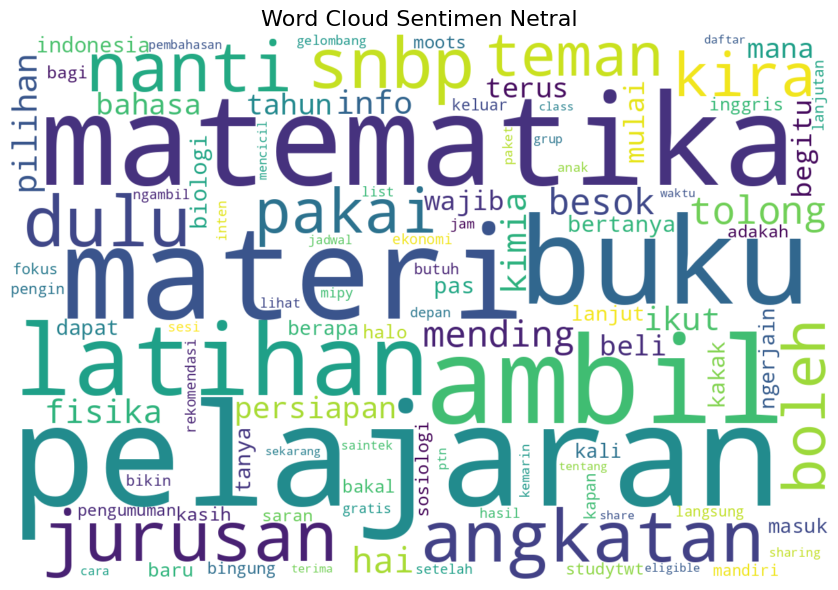

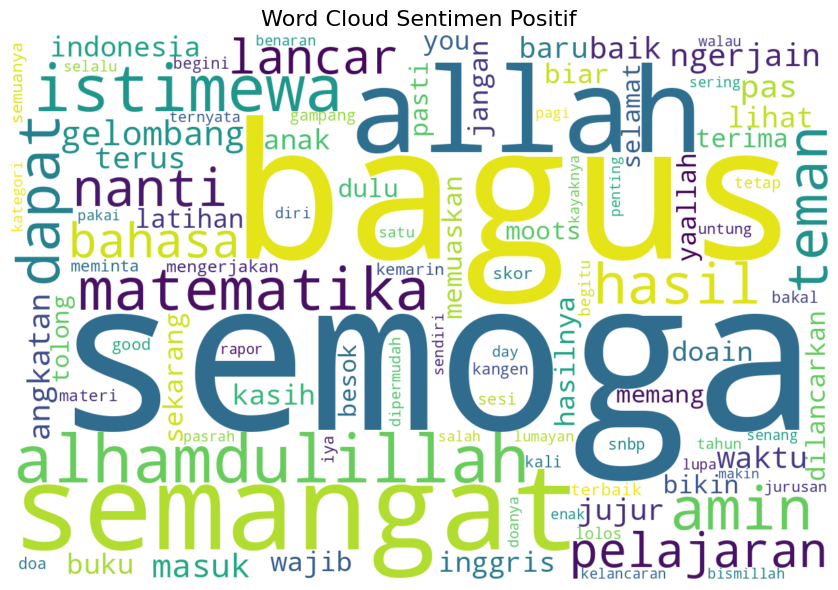

In [ ]:
for sentimen in sentimen_order:
    data_sentimen = df[df["sentimen"] == sentimen]

    create_wordcloud(
        text_series=data_sentimen["normalized"],
        stopwords=stopwords_final,
        title=f"Word Cloud Sentimen {sentimen.capitalize()}",
        filename=f"wordcloud_sentimen_{sentimen}.png"
    )

# Gold standard


In [ ]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report

# Coba baca CSV dengan encoding yang lebih fleksibel
test_df = pd.read_csv("test_dataset.csv", encoding="latin1")


print(test_df.columns)

Index(['full_text', 'normalized', 'label_num', 'pseudo_label',
       'confidence_score', 'num_old', 'label_old', 'Unnamed: 7', 'Unnamed: 8',
       '103'],
      dtype='object')


In [ ]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score, confusion_matrix

# Pastikan kolom tidak ada spasi tersembunyi
test_df.columns = test_df.columns.str.strip()

# Ubah ke integer
test_clean["num_old"] = test_clean["num_old"].astype(int)
test_clean["label_num"] = test_clean["label_num"].astype(int)

# Hitung jumlah sesuai dan berbeda
jumlah_sesuai = (test_clean["num_old"] == test_clean["label_num"]).sum()
jumlah_berbeda = (test_clean["num_old"] != test_clean["label_num"]).sum()
total_data = len(test_clean)

persen_sesuai = jumlah_sesuai / total_data * 100
persen_berbeda = jumlah_berbeda / total_data * 100

print("Total data:", total_data)
print("Jumlah sesuai:", jumlah_sesuai)
print("Jumlah berbeda:", jumlah_berbeda)
print("Persentase sesuai:", persen_sesuai)
print("Persentase berbeda:", persen_berbeda)

# Cohen's Kappa
kappa = cohen_kappa_score(test_clean["label_num"], test_clean["num_old"])
print("Cohen's Kappa:", kappa)


Total data: 884
Jumlah sesuai: 781
Jumlah berbeda: 103
Persentase sesuai: 88.34841628959276
Persentase berbeda: 11.65158371040724
Cohen's Kappa: 0.8089763412797151


In [ ]:
kesesuaian_df = pd.DataFrame({
    "Keterangan": [
        "Pseudo-label sesuai dengan gold standard",
        "Pseudo-label berbeda dengan gold standard",
        "Total"
    ],
    "Jumlah Data": [
        jumlah_sesuai,
        jumlah_berbeda,
        total_data
    ],
    "Persentase": [
        f"{persen_sesuai:.2f}%",
        f"{persen_berbeda:.2f}%",
        "100%"
    ]
})

kesesuaian_df

,Keterangan,Jumlah Data,Persentase
0,Pseudo-label sesuai dengan gold standard,781,88.35%
1,Pseudo-label berbeda dengan gold standard,103,11.65%
2,Total,884,100%


In [ ]:
label_names = ["positif", "netral", "negatif"]

crosstab = pd.crosstab(
    test_df["label_num"].map({0: "positif", 1: "netral", 2: "negatif"}),
    test_df["num_old"].map({0: "positif", 1: "netral", 2: "negatif"}),
    rownames=["Gold Standard"],
    colnames=["Pseudo-label"]
)

crosstab

Pseudo-label,negatif,netral,positif
Gold Standard,,,
negatif,398,21,9
netral,34,267,8
positif,15,16,116
